# Наивный Байес (Naive Bayes)

## Теория

Наивный байесовский классификатор — это семейство вероятностных алгоритмов, основанных на **теореме Байеса** с допущением о **условной независимости** признаков:

$$P(y \mid x_1, \dots, x_n) = \frac{P(y) \cdot \prod_{i=1}^{n} P(x_i \mid y)}{P(x_1, \dots, x_n)}$$

Модель выбирает класс с наибольшей апостериорной вероятностью:

$$\hat{y} = \arg\max_y P(y) \cdot \prod_{i=1}^{n} P(x_i \mid y)$$

### Разновидности

| Вариант | Предположение о распределении признаков | Типичное применение |
|---|---|---|
| **GaussianNB** | Нормальное распределение | Вещественные признаки |
| **MultinomialNB** | Мультиномиальное распределение | Текстовая классификация (частоты слов) |
| **BernoulliNB** | Бернуллиево распределение | Бинарные признаки |

## Датасет

В работе используется датасет **Breast Cancer Wisconsin** из библиотеки `sklearn`.

Он содержит характеристики клеточных ядер, полученные из оцифрованных изображений тонкоигольной аспирационной биопсии (FNA) молочной железы.  
Задача модели — по набору признаков определить, является ли опухоль **доброкачественной** (benign) или **злокачественной** (malignant).

В датасете:
- **569 объектов** — образцы биопсии,
- **30 признаков** — числовые характеристики клеточных ядер,
- **2 класса** — `malignant` (0) и `benign` (1).

Датасет изначально создан для задачи **бинарной классификации** в медицинской диагностике: определить, является опухоль злокачественной или доброкачественной. Это ключевой клинический вопрос при обследовании молочной железы — от ответа зависит тактика лечения.

- **malignant (0)** — злокачественная опухоль. Характеризуется более крупными ядрами, неровным контуром, выраженной вогнутостью и высокой вариабельностью формы. Таких образцов **212** (~37%).
- **benign (1)** — доброкачественная опухоль. Ядра, как правило, меньше, контур ровнее, признаки менее вариабельны. Таких образцов **357** (~63%).

### Описание признаков

Для каждого изображения биопсии вычислены 10 базовых характеристик клеточного ядра, и для каждой из них рассчитаны три статистики: **среднее** (mean), **стандартная ошибка** (se) и **наихудшее значение** (worst — среднее трёх наибольших значений). Итого 10 × 3 = 30 признаков.

| Базовый признак | Перевод | Описание |
|---|---|---|
| **radius** | радиус | среднее расстояние от центра ядра до точек его контура |
| **texture** | текстура | стандартное отклонение яркости пикселей (оттенки серого) |
| **perimeter** | периметр | длина контура ядра |
| **area** | площадь | площадь ядра |
| **smoothness** | гладкость | локальная вариация длин радиусов |
| **compactness** | компактность | периметр² / площадь − 1.0 |
| **concavity** | вогнутость | степень вогнутости контура ядра |
| **concave points** | вогнутые точки | количество вогнутых участков контура |
| **symmetry** | симметрия | симметричность ядра |
| **fractal dimension** | фрактальная размерность | сложность контура (аппроксимация «береговой линии» − 1) |

Каждый из 10 признаков представлен тремя колонками:
- `mean ...` — среднее значение по всем ядрам на изображении,
- `... error` — стандартная ошибка,
- `worst ...` — наихудшее (наибольшее из средних трёх крайних значений).

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и инструменты `sklearn` для наивного байесовского классификатора, оценки вероятностей и метрик качества


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [2]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

feature_names = cancer.feature_names
target_names = cancer.target_names

print("Размер матрицы признаков X:", X.shape)
print("Размер целевой переменной y:", y.shape)
print("\nНазвания классов:", target_names)
print("\nПервые 5 признаков:", feature_names[:5])

Размер матрицы признаков X: (569, 30)
Размер целевой переменной y: (569,)

Названия классов: ['malignant' 'benign']

Первые 5 признаков: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [3]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Базовые статистики датасета

In [4]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Количество объектов каждого класса:")
for class_id, count in class_counts.items():
    print(f"  {target_names[class_id]} ({class_id}): {count}")

Количество объектов каждого класса:
  malignant (0): 212
  benign (1): 357


## Тепловая карта

Строим тепловую карту корреляций между признаками датасета `Breast Cancer Wisconsin`


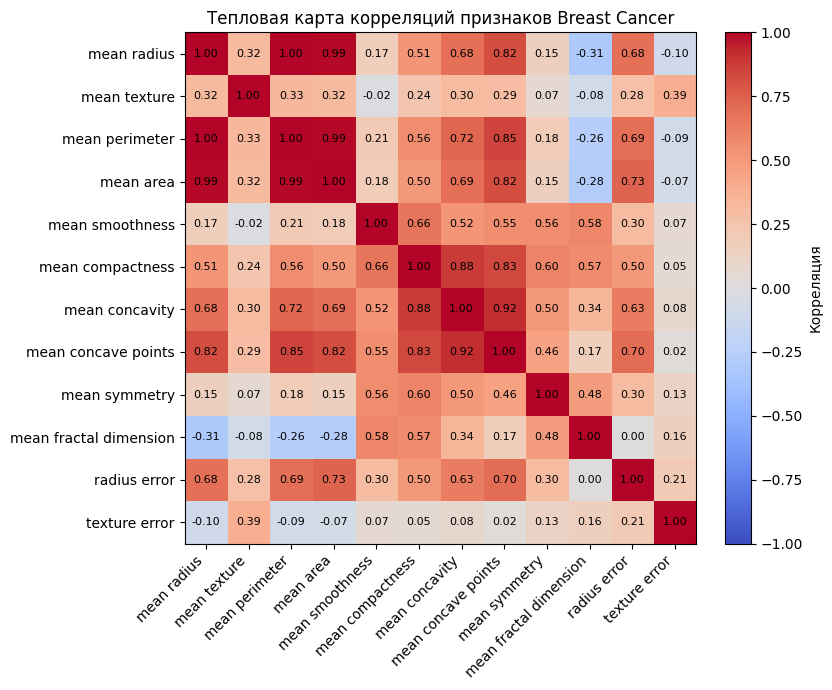

In [5]:
heatmap_features = list(feature_names)
if len(heatmap_features) > 12:
    heatmap_features = heatmap_features[:12]

corr_matrix = df[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков Breast Cancer')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (455, 30)
Размер тестовой выборки: (114, 30)


## Обучение GaussianNB

In [7]:
gnb_model = GaussianNB(
    var_smoothing=1e-9  # сглаживание дисперсии (по умолчанию)
)

gnb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Прогнозы модели

Анализируем предсказанные классы и их вероятности на тестовой выборке


In [8]:
y_pred = gnb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



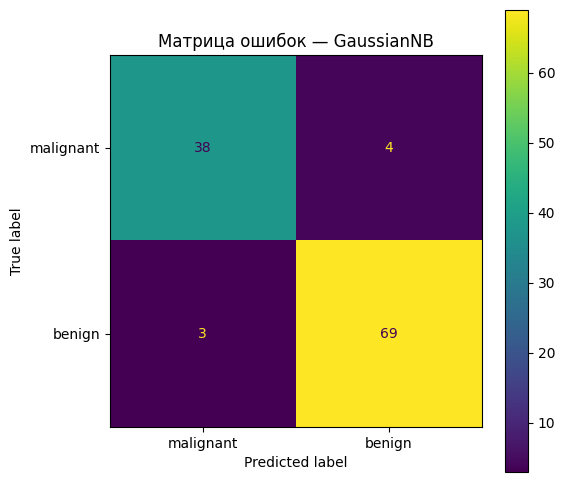

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    ax=ax
)
plt.title("Матрица ошибок — GaussianNB")
plt.show()

## Влияние параметра var_smoothing

Исследуем, как меняется качество при разных значениях сглаживания.

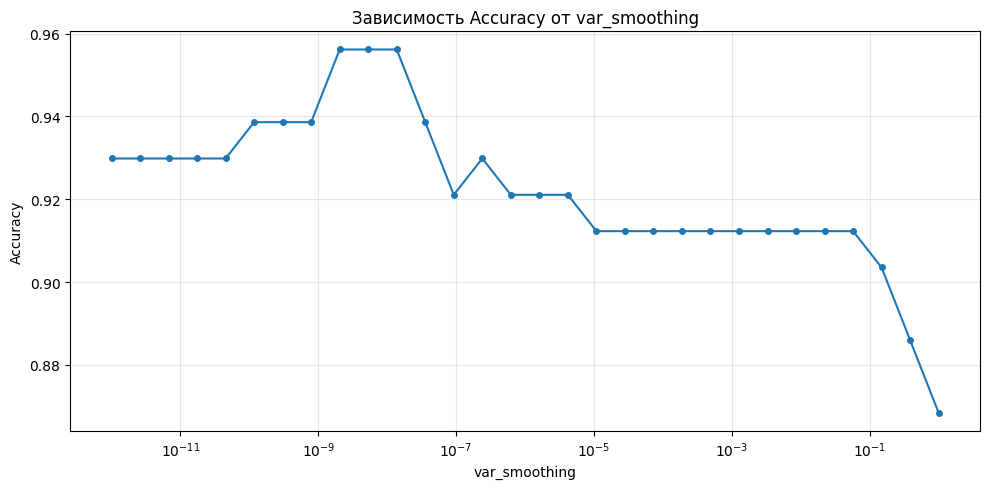

Лучшее var_smoothing: 2.04e-09, Accuracy: 0.9561


In [10]:
smoothing_values = np.logspace(-12, 0, 30)
accuracies = []

for vs in smoothing_values:
    model = GaussianNB(var_smoothing=vs)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(10, 5))
plt.plot(smoothing_values, accuracies, marker='o', markersize=4)
plt.xscale('log')
plt.xlabel('var_smoothing')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от var_smoothing')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = np.argmax(accuracies)
print(f"Лучшее var_smoothing: {smoothing_values[best_idx]:.2e}, Accuracy: {accuracies[best_idx]:.4f}")

## Визуализация: вероятности предсказаний

Смотрим распределение апостериорных вероятностей для тестовой выборки.

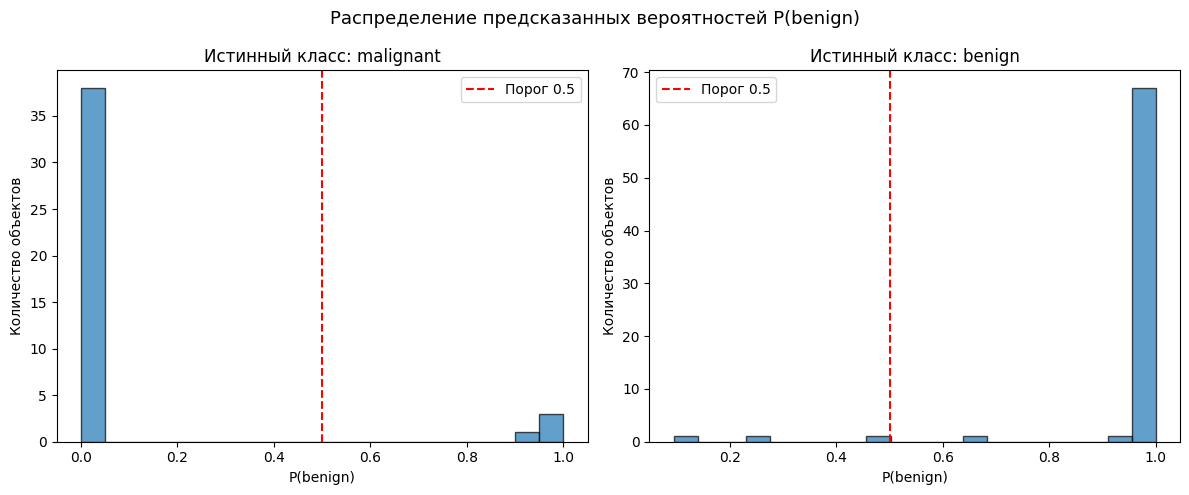

In [11]:
y_proba = gnb_model.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for cls_idx, cls_name in enumerate(target_names):
    mask = y_test == cls_idx
    axes[cls_idx].hist(y_proba[mask, 1], bins=20, alpha=0.7, edgecolor='black')
    axes[cls_idx].set_title(f'Истинный класс: {cls_name}')
    axes[cls_idx].set_xlabel('P(benign)')
    axes[cls_idx].set_ylabel('Количество объектов')
    axes[cls_idx].axvline(x=0.5, color='red', linestyle='--', label='Порог 0.5')
    axes[cls_idx].legend()

plt.suptitle('Распределение предсказанных вероятностей P(benign)', fontsize=13)
plt.tight_layout()
plt.show()

## Влияние масштабирования признаков

GaussianNB оценивает параметры распределения самостоятельно, поэтому масштабирование не должно существенно влиять на результат. Проверим это.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = gnb_scaled.predict(X_test_scaled)

acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy без масштабирования: {accuracy:.4f}")
print(f"Accuracy с масштабированием:  {acc_scaled:.4f}")
print(f"\nРазница: {abs(accuracy - acc_scaled):.4f}")

Accuracy без масштабирования: 0.9386
Accuracy с масштабированием:  0.9298

Разница: 0.0088
